# PatchCore AI 학습 노트: hc- sr04 모듈 front

### Colab으로 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()   # hc_sr04.zip 선택해서 업로드

Saving hc_sr04.zip to hc_sr04.zip


### zip 파일 압축 해제

In [ ]:
!unzip -q hc_sr04.zip -d /content/pcb_dataset
!ls /content/pcb_dataset/hc_sr04/normal | wc -l
!ls /content/pcb_dataset/hc_sr04/abnormal | wc -l

300
50


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q "anomalib[full,cu126]"

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.7/829.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 84.5 MB/s eta 0:00:00
   ━━

In [ ]:
from anomalib.data import Folder

datamodule = Folder(
    name="hc_sr04",
    root="/content/pcb_dataset/hc_sr04",
    normal_dir="normal",
    abnormal_dir="abnormal",
    normal_split_ratio=0.2,   # normal 중 일부를 test용으로 자동 분할
    train_batch_size=8,
    eval_batch_size=8,
    num_workers=2,
)
datamodule.setup()

### 5. 학습(resnet18 + fp16)

In [ ]:
from anomalib.models import Patchcore
from anomalib.engine import Engine

model_01 = Patchcore(
    backbone="resnet18",
    layers=["layer2", "layer3"],
    coreset_sampling_ratio=0.15,
)

VERSION = "model_01"   # 다음번엔 model_02로 바꿔서 비교 가능

engine_01 = Engine(
    max_epochs=1,
    accelerator="gpu",
    enable_progress_bar=False,
    default_root_dir=f"/content/results/hc_sr04_{VERSION}",
)

engine_01.fit(model=model_01, datamodule=datamodule)

INFO:lightning_fabric.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:lightning_fabric.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │  2.8 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Selecting Coreset Indices.: 100%|██████████| 36863/36863 [02:31<00:00, 244.01it/s]
INFO:lightning_fabric.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


### 6. 평가

In [ ]:
engine_01.test(model=model_01, datamodule=datamodule)

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │     0.997333288192749     │
│       image_F1Score       │    0.8372092843055725     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.997333288192749, 'image_F1Score': 0.8372092843055725}]

#### 7. drive 백업 + export

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
from pathlib import Path

DRIVE_BACKUP = "/content/drive/MyDrive/AI_MachineLearning/boardguard"
dest = Path(DRIVE_BACKUP) / "results_hc_sr04_real"
dest.parent.mkdir(parents=True, exist_ok=True)
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree("/content/results/hc_sr04", dest)

PosixPath('/content/drive/MyDrive/AI_MachineLearning/boardguard/results_hc_sr04_real')

In [ ]:
from anomalib.deploy import ExportType

engine_01.export(model=model_01, export_type=ExportType.ONNX, export_root="/content/export/hc_sr04")

export_dest = Path(DRIVE_BACKUP) / "export_hc_sr04_real"
if export_dest.exists():
    shutil.rmtree(export_dest)
shutil.copytree("/content/export/hc_sr04", export_dest)

/usr/local/lib/python3.13/dist-packages/anomalib/models/components/base/export_mixin/mixin.py:200: FutureWarning: The legacy ONNX exporter path (`dynamo=False`) is deprecated and will be removed in anomalib 2.7.0. Minimum required PyTorch version will increase to 2.10 in anomalib 2.7.0. Install `anomalib[openvino]` and migrate to `dynamo=True`.
  warn_legacy_onnx_exporter_deprecation()
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/patchcore/torch_model.py:180: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.memory_bank.size(0) == 0:
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/patchcore/torch_model.py:349: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of

PosixPath('/content/drive/MyDrive/AI_MachineLearning/boardguard/export_hc_sr04_real')

#### heatmap으로 실제 *확인*

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


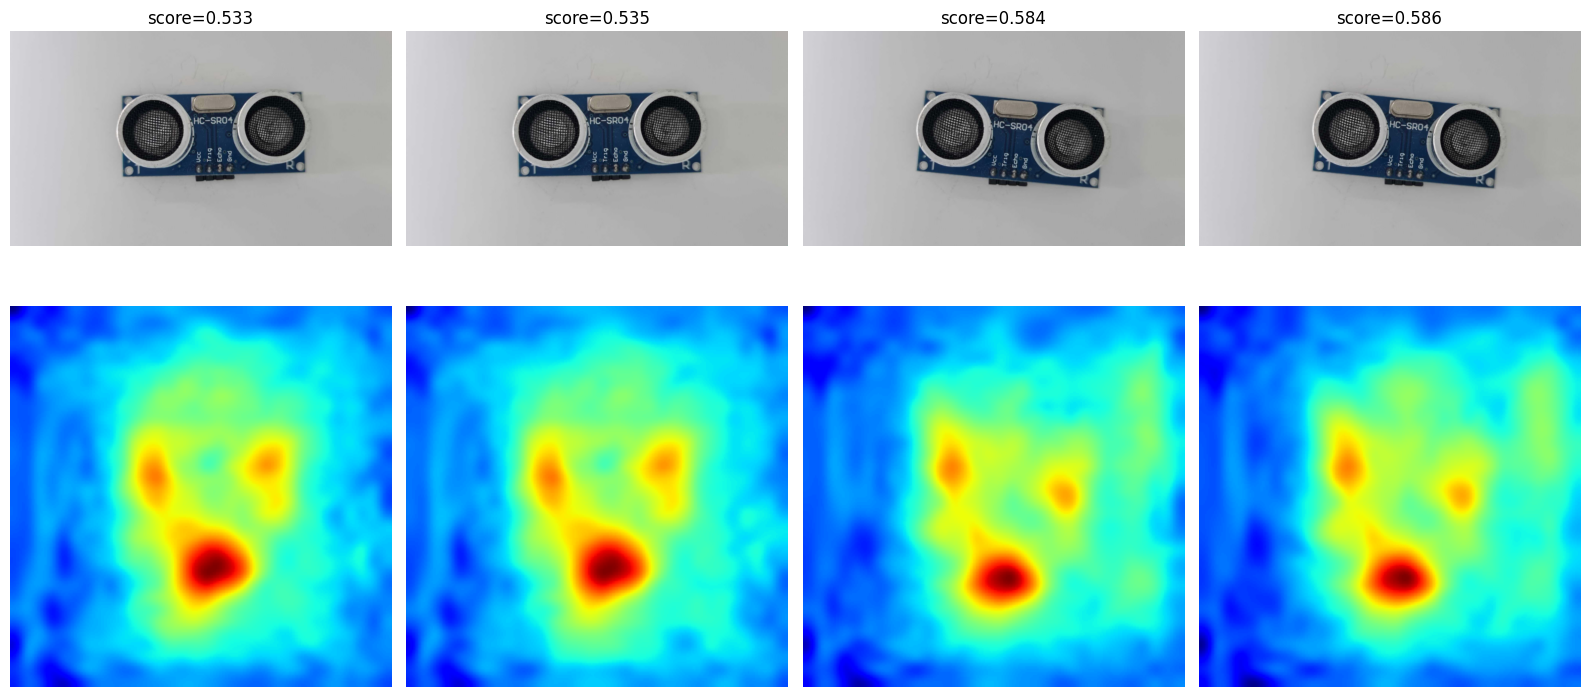

In [ ]:
from anomalib.data import PredictDataset

bad_dir = "/content/pcb_dataset/hc_sr04/abnormal"
predict_dataset = PredictDataset(path=bad_dir, image_size=(256, 256))
predictions = engine.predict(model=model, dataset=predict_dataset)

import matplotlib.pyplot as plt
samples = predictions[:4]
fig, axes = plt.subplots(2, len(samples), figsize=(4 * len(samples), 8))
for i, pred in enumerate(samples):
    axes[0, i].imshow(plt.imread(pred.image_path[0]))
    axes[0, i].set_title(f"score={float(pred.pred_score[0]):.3f}")
    axes[0, i].axis("off")
    axes[1, i].imshow(pred.anomaly_map[0].squeeze().cpu().numpy(), cmap="jet")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

#### 정상 사진들의 score 분포

In [ ]:
import numpy as np
from anomalib.data import PredictDataset

normal_dir = "/content/pcb_dataset/hc_sr04/normal"
predict_dataset = PredictDataset(path=normal_dir, image_size=(256, 256))
predictions = engine_01.predict(model=model_01, dataset=predict_dataset)

scores = [float(p.pred_score[0]) for p in predictions]
print("정상 score 평균:", np.mean(scores))
print("정상 score 최댓값:", np.max(scores))
print("정상 score 분포:", np.percentile(scores, [50, 90, 95, 99]))

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


정상 score 평균: 0.11669758610103441
정상 score 최댓값: 0.4827079176902771
정상 score 분포: [0.10660842 0.14845071 0.17778411 0.25366171]


In [ ]:
import numpy as np

high_score_idx = [i for i, s in enumerate(scores) if s > 0.4]
for i in high_score_idx:
    print(predictions[i].image_path[0], scores[i])

/content/pcb_dataset/hc_sr04/normal/0033.jpg 0.536109447479248


In [ ]:
abnormal_dir = "/content/pcb_dataset/hc_sr04/abnormal"
abnormal_dataset = PredictDataset(path=abnormal_dir, image_size=(256, 256))
abnormal_predictions = engine_01.predict(model=model_01, dataset=abnormal_dataset)
abnormal_scores = [float(p.pred_score[0]) for p in abnormal_predictions]
print("불량 score 최솟값:", np.min(abnormal_scores))
print("불량 score 목록:", sorted(abnormal_scores))

INFO:lightning_fabric.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


불량 score 최솟값: 0.47793763875961304
불량 score 목록: [0.47793763875961304, 0.47851628065109253, 0.48588842153549194, 0.48649439215660095, 0.4882265627384186, 0.49308913946151733, 0.49940431118011475, 0.5000012516975403, 0.5002617239952087, 0.5119050741195679, 0.5128074884414673, 0.5177721381187439, 0.5193080902099609, 0.5208532214164734, 0.5250741839408875, 0.5250777006149292, 0.5269117951393127, 0.5305616855621338, 0.5313225984573364, 0.5411828756332397, 0.5434633493423462, 0.5836049318313599, 0.5860806703567505, 0.597082257270813, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
extreme_idx = [i for i, s in enumerate(abnormal_scores) if s > 0.9]
for i in extreme_idx:
    print(abnormal_predictions[i].image_path[0], abnormal_scores[i])

/content/pcb_dataset/hc_sr04/abnormal/0018.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0019.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0020.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0021.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0022.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0023.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0024.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0025.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0026.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0027.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0028.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0029.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0030.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0031.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0032.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0033.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0034.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0035.jpg 1.0
/content/pcb_dataset/hc_sr04/abnormal/0036.jpg 1.0
/content/pcb_dataset/hc_sr04/ab

In [ ]:
# threshold를 0.48로 낮춰서 confusion 확인
threshold = 0.48

fp = sum(1 for s in scores if s > threshold)  # 정상인데 FAIL로 오판
fn = sum(1 for s in abnormal_scores if s <= threshold)  # 불량인데 PASS로 오판

print(f"정상 오탐(FP): {fp} / {len(scores)}")
print(f"불량 놓침(FN): {fn} / {len(abnormal_scores)}")

정상 오탐(FP): 1 / 299
불량 놓침(FN): 2 / 50


In [ ]:
from anomalib.deploy import ExportType
import shutil
from pathlib import Path

engine_01.export(model=model_01, export_type=ExportType.ONNX, export_root="/content/export/hc_sr04_model_01")

DRIVE_BACKUP = "/content/drive/MyDrive/AI_MachineLearning/boardguard"
export_dest = Path(DRIVE_BACKUP) / "export_hc_sr04_model_01"
if export_dest.exists():
    shutil.rmtree(export_dest)
shutil.copytree("/content/export/hc_sr04_model_01", export_dest)

/usr/local/lib/python3.13/dist-packages/anomalib/models/components/base/export_mixin/mixin.py:200: FutureWarning: The legacy ONNX exporter path (`dynamo=False`) is deprecated and will be removed in anomalib 2.7.0. Minimum required PyTorch version will increase to 2.10 in anomalib 2.7.0. Install `anomalib[openvino]` and migrate to `dynamo=True`.
  warn_legacy_onnx_exporter_deprecation()
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/patchcore/torch_model.py:180: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.memory_bank.size(0) == 0:
/usr/local/lib/python3.13/dist-packages/anomalib/models/image/patchcore/torch_model.py:349: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of

PosixPath('/content/drive/MyDrive/AI_MachineLearning/boardguard/export_hc_sr04_model_01')